In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_excel('dataset/EastWestAirlines.xlsx',sheet_name=1)

In [21]:
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


## Data Preprocessing:

**1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary.**

**2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.**

**3.	Use multiple visualizations to understand the hidden patterns in the dataset**


In [23]:
# Check mising value
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

No missing values present in the dataset.

In [24]:
# ID column not needed

df_clust = df.drop(['ID#'],axis=1)

ID# is just a unique identifier and does not contribute to clustering.

In [25]:
df_clust.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


In [26]:
df_clust.dtypes

Balance              int64
Qual_miles           int64
cc1_miles            int64
cc2_miles            int64
cc3_miles            int64
Bonus_miles          int64
Bonus_trans          int64
Flight_miles_12mo    int64
Flight_trans_12      int64
Days_since_enroll    int64
Award?               int64
dtype: object

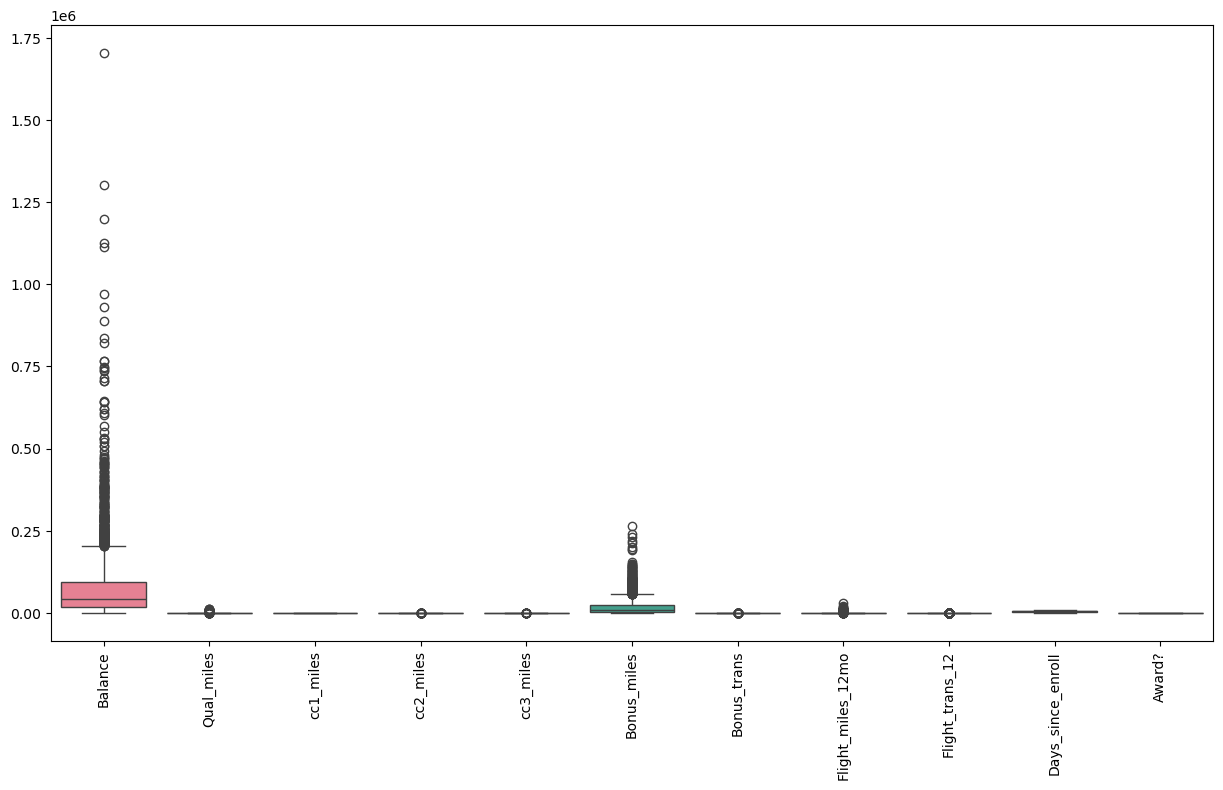

In [27]:
# Checking outliers

plt.figure(figsize=(15,8))
sns.boxplot(data=df_clust)
plt.xticks(rotation=90)
plt.show()

In [28]:
for col in df_clust.columns:
    
    Q1 = df_clust[col].quantile(0.25)
    Q3 = df_clust[col].quantile(0.75)
    IQR = Q3-Q1
    
    UE = Q3 + 1.5*IQR
    LE = Q1 - 1.5*IQR
    
    df_clust.loc[df[col] > UE, col] = UE
    df_clust.loc[df[col] < LE, col] = LE

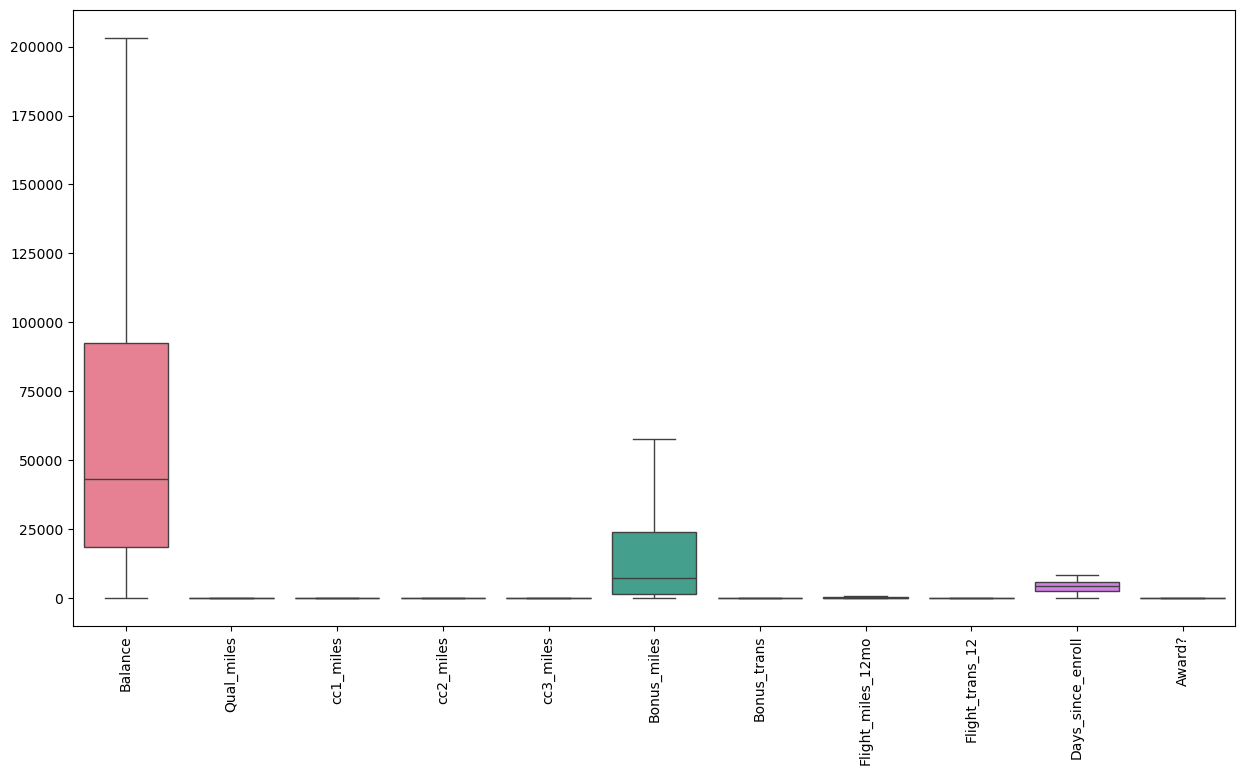

In [29]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df_clust)
plt.xticks(rotation=90)
plt.show()

Outliers were identified and treated using IQR method to improve clustering quality.

Since features are on different scales:

* Balance → Thousands

* cc1_miles → 1–5

Therefore, We must standardize.

In [30]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

df_scaled = sc.fit_transform(df_clust)

df_scaled = pd.DataFrame(df_scaled, columns=df_clust.columns)

In [31]:
df_scaled

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.607258,0.0,-0.769578,0.0,0.0,-0.843091,-1.148854,-0.604313,-0.626143,1.395454,-0.766919
1,-0.758947,0.0,-0.769578,0.0,0.0,-0.840822,-1.039133,-0.604313,-0.626143,1.379957,-0.766919
2,-0.382070,0.0,-0.769578,0.0,0.0,-0.624581,-0.819689,-0.604313,-0.626143,1.411920,-0.766919
3,-0.835106,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,-0.604313,-0.626143,1.372208,-0.766919
4,0.579265,0.0,1.409471,0.0,0.0,1.543191,1.594189,2.034489,2.020176,1.363975,1.303918
...,...,...,...,...,...,...,...,...,...,...,...
3994,-0.772038,0.0,-0.769578,0.0,0.0,-0.381007,-0.819689,0.074478,0.432384,-1.315120,1.303918
3995,0.010506,0.0,-0.769578,0.0,0.0,-0.798437,-0.709967,-0.604313,-0.626143,-1.318994,1.303918
3996,0.167530,0.0,0.683121,0.0,0.0,0.555335,-0.380802,-0.604313,-0.626143,-1.315604,1.303918
3997,-0.151188,0.0,-0.769578,0.0,0.0,-0.825052,-1.148854,1.092666,0.432384,-1.316088,-0.766919


In [32]:
df_clust.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3999.0,3999.000000,3999.0,3999.0,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000
mean,63768.635784,0.0,2.059515,1.0,1.0,15410.730683,11.470618,178.055639,0.591523,4118.55939,0.370343
std,58673.700736,0.0,1.376919,0.0,0.0,18074.733482,9.115104,294.678028,0.944826,2065.13454,0.482957
min,0.000000,0.0,1.000000,1.0,1.0,0.000000,0.000000,0.000000,0.000000,2.00000,0.000000
25%,18527.500000,0.0,1.000000,1.0,1.0,1250.000000,3.000000,0.000000,0.000000,2330.00000,0.000000
50%,43097.000000,0.0,1.000000,1.0,1.0,7171.000000,12.000000,0.000000,0.000000,4096.00000,0.000000
75%,92404.000000,0.0,3.000000,1.0,1.0,23800.500000,17.000000,311.000000,1.000000,5790.50000,1.000000
max,203218.750000,0.0,5.000000,1.0,1.0,57626.250000,38.000000,777.500000,2.500000,8296.00000,1.000000


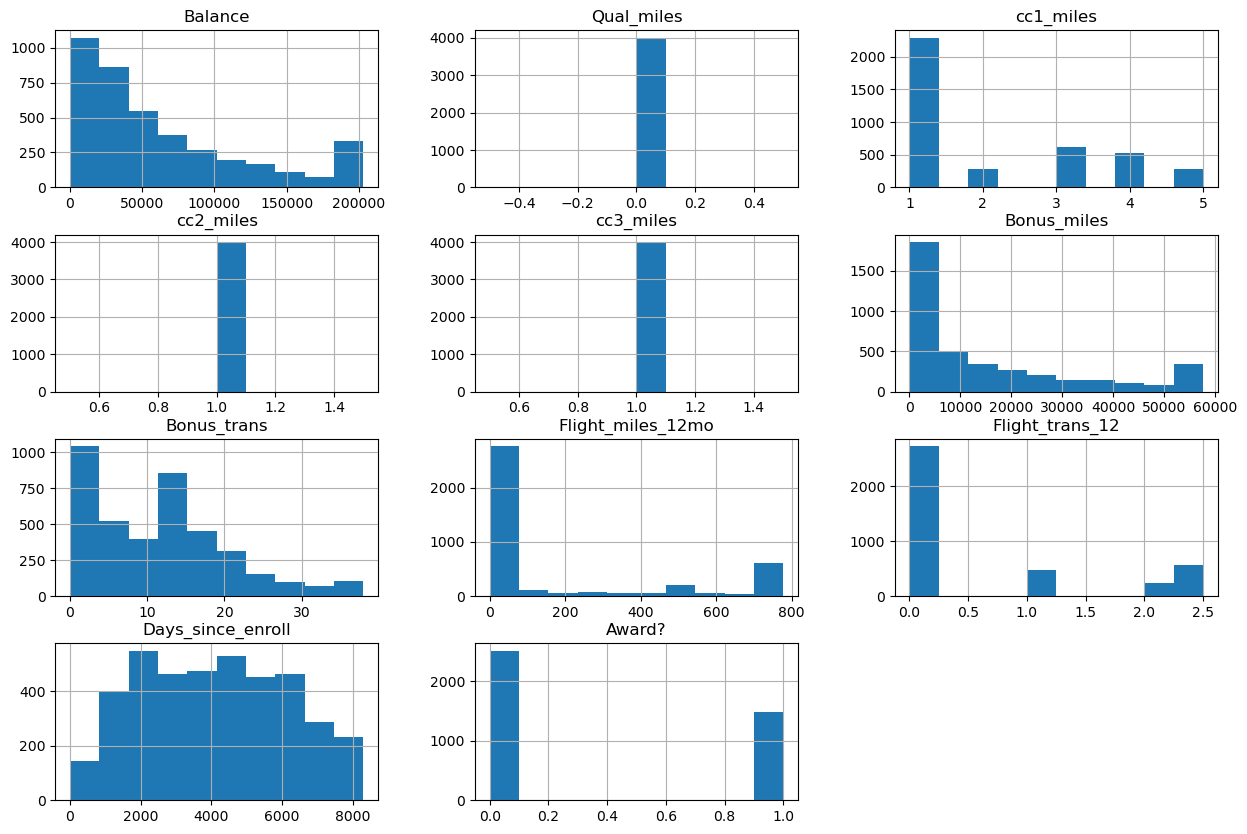

In [33]:
df_clust.hist(figsize=(15,10), bins=10)
plt.show()

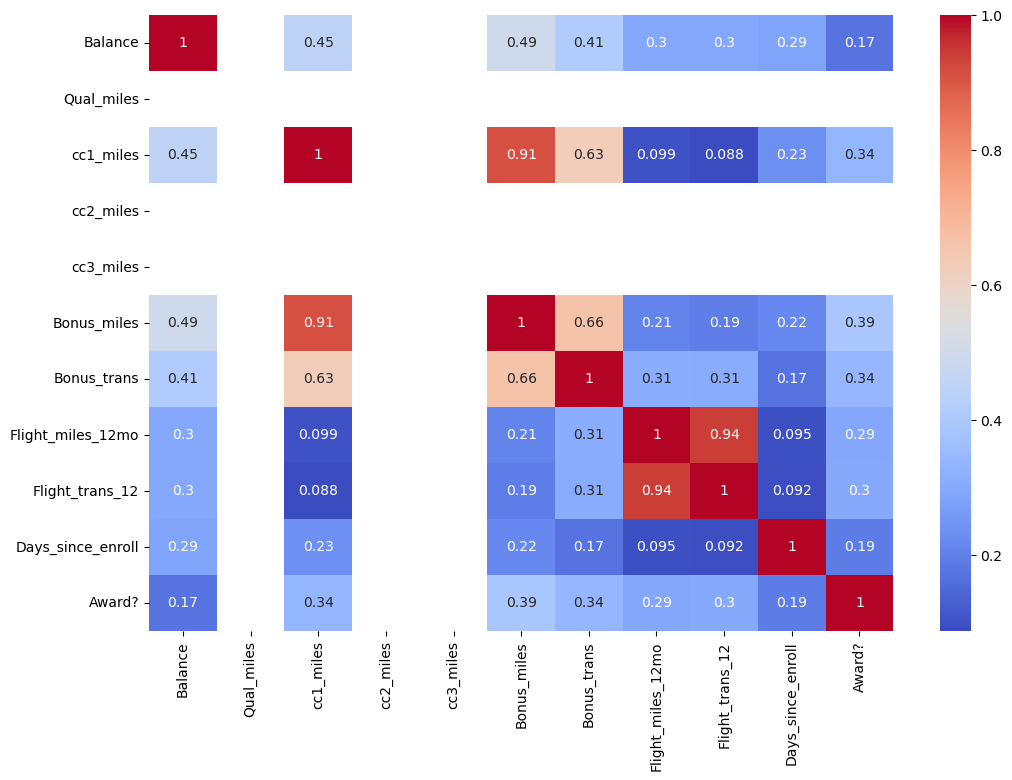

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(df_clust.corr(), annot=True, cmap='coolwarm')
plt.show()

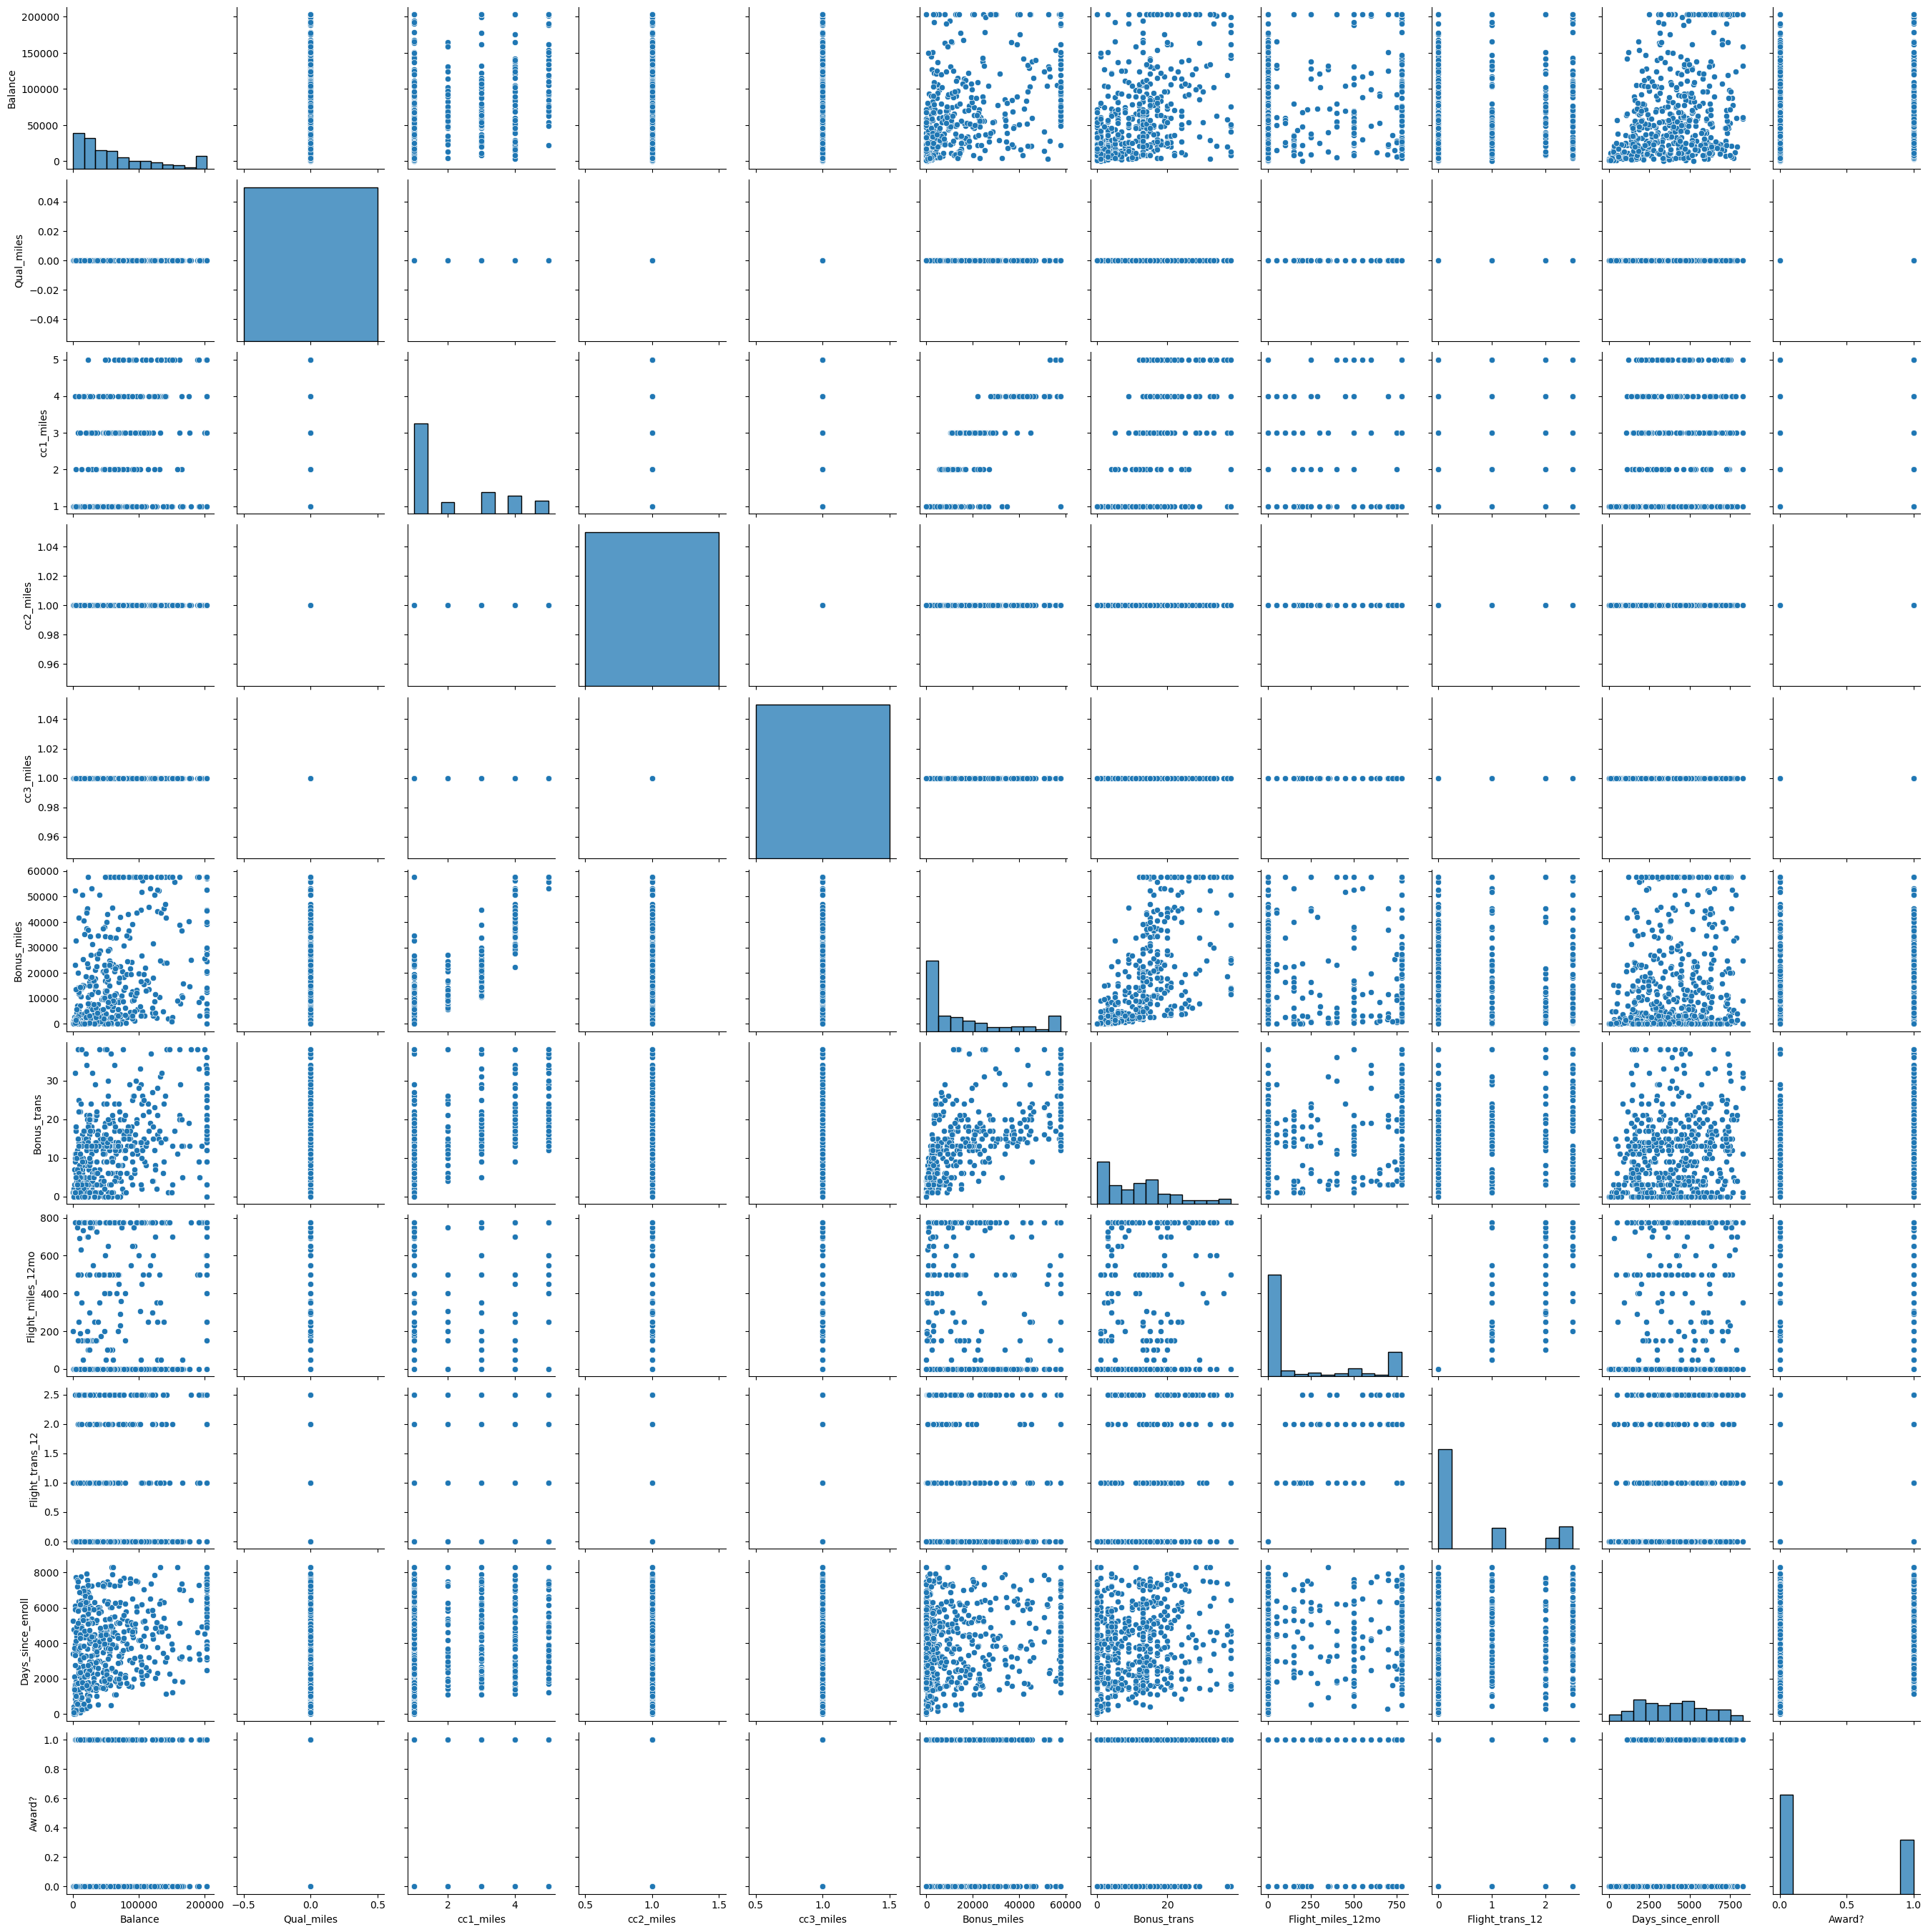

In [35]:
sns.pairplot(df_clust.sample(500))
plt.show()

* The dataset contained no missing values.

* ID column was removed as it is not relevant for clustering.

* Outliers were detected using boxplots and treated using IQR method.

* Since clustering is distance-based, features were standardized using StandardScaler.

* EDA revealed skewed distributions and strong correlations among flight-related and bonus-related features.

## Implementing Clustering Algorithms:

**Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.**

**Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data.**

**Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.**


In [36]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [39]:
import warnings
warnings.filterwarnings('ignore')

In [40]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)
    

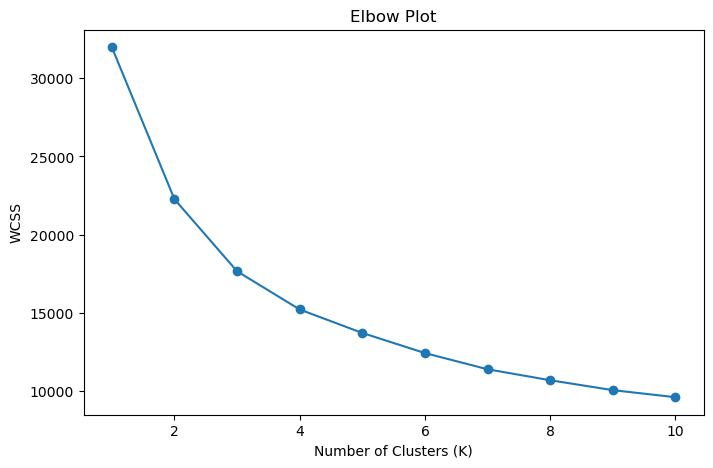

In [63]:
# Elbow plot

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.show()

The elbow appears around K = 4, indicating that 4 clusters provide a good balance between model complexity and variance reduction.

In [72]:
# Assuming K = 4 from the elbow plot

kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_labels = kmeans.fit_predict(df_scaled)

In [73]:
df_clust['KMeans_Cluster'] = kmeans_labels

df_clust['KMeans_Cluster']

0       0
1       0
2       0
3       0
4       2
       ..
3994    0
3995    0
3996    1
3997    0
3998    0
Name: KMeans_Cluster, Length: 3999, dtype: int32

In [74]:
# Evaluating the clusters

sil_score = silhouette_score(df_scaled, kmeans_labels)
print('Silhoutte Score for KMeans: ', sil_score)

Silhoutte Score for KMeans:  0.3072097778571253


Silhouette Score ranges from -1 to +1.

* > 0.5 → Strong clustering

* 0.25 – 0.5 → Moderate clustering

* < 0.25 → Weak clustering

The obtained Score = 0.307 which indicates

* Moderate cluster separation

* Clusters are reasonably formed

* Some overlap exists between clusters

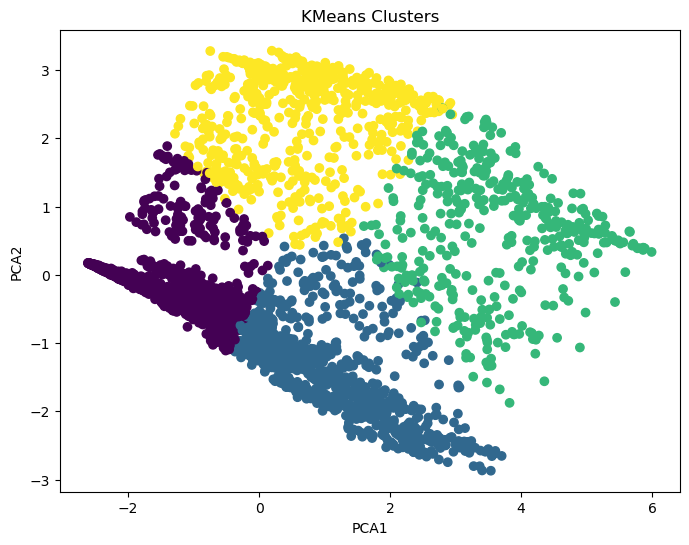

In [75]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=kmeans_labels)
plt.title("KMeans Clusters")
plt.xlabel('PCA1')
plt.ylabel("PCA2")
plt.show()

From the K-Means PCA plot:

* Four clearly distinguishable groups are visible.

* Clusters are relatively compact.

* Some overlap exists in boundary regions.

In [47]:
# DBSCAN Clustering

from sklearn.cluster import DBSCAN

In [59]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(df_scaled)

df_clust['DBSCAN_CLuster'] = db_labels

In [60]:
# No. of Clusters

np.unique(db_labels)

array([-1,  0,  1], dtype=int64)

This indicates:

* 2 clusters: (Cluster 0 and Cluster 1)

* -1 represents noise points (outliers)

In [61]:
# Remove noise for silhoutte score

mask = db_labels != -1

if len(set(db_labels[mask])) > 1:
    db_sil_score = silhouette_score(df_scaled[mask], db_labels[mask])
    print("Silhouette Score for DBSCAN:", db_sil_score)
else:
    print("Silhouette Score cannot be calculated (only one cluster found)")

Silhouette Score for DBSCAN: 0.24359620653866218


This is lower than K-Means.

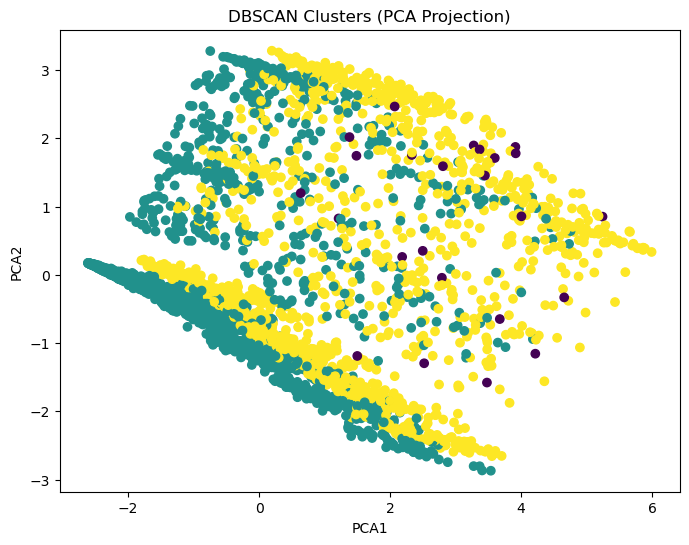

In [62]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=db_labels)
plt.title("DBSCAN Clusters (PCA Projection)")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.show()

From the PCA visualization:

* Clusters overlap significantly.

* Noise points are scattered.

* Boundaries are not as clear as K-Means.

In [67]:
for eps in [0.5, 1.0, 1.5, 2.0,2.5]:
    db = DBSCAN(eps=eps, min_samples=5)
    labels = db.fit_predict(df_scaled)
    print("Eps:", eps, "Clusters:", len(set(labels)))

Eps: 0.5 Clusters: 34
Eps: 1.0 Clusters: 17
Eps: 1.5 Clusters: 3
Eps: 2.0 Clusters: 3
Eps: 2.5 Clusters: 1


* Smaller eps values produced too many small clusters (over-segmentation).

* Larger eps values merged most data into a single cluster.

* Stable clustering was observed between eps = 1.5 and 2.0.

## Cluster Analysis and Interpretation:

**Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.**

In [77]:
cluster_summary = df_clust.groupby('KMeans_Cluster').mean()
cluster_summary

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,DBSCAN_CLuster
KMeans_Cluster,,,,,,,,,,,,
0,32775.089764,0.0,1.130709,1.0,1.0,3436.233596,5.967454,14.991601,0.074541,3556.425722,0.149081,0.149081
1,88703.363827,0.0,3.458101,1.0,1.0,30268.763501,16.756983,25.334264,0.112663,4766.836127,0.519553,0.516760
2,125077.225686,0.0,4.024938,1.0,1.0,44366.632793,24.927681,638.718204,2.018703,5041.586035,0.802993,0.738155
3,76172.614297,0.0,1.218094,1.0,1.0,7725.065024,10.516963,646.446688,2.088853,4125.799677,0.512116,0.500808


### K-Means Cluster Analysis (K = 4)

Based on the PCA visualization and clustering results, K-Means formed 4 distinct customer segments.

**Cluster 0 – Low Activity Customers**

* Low balance and low flight transactions.

* Few bonus miles.

* Likely new or inactive customers.

**Cluster 1 – Moderate Loyalty Customers** 

* High flight miles and high flight transactions.

* Moderate bonus activity.

* Regular travelers contributing steady revenue.

**Cluster 2 – High Loyalty / Premium Customers**

* Very high balance and bonus miles.

* Higher qualifying miles.

* Likely long-term and valuable customers.

**Cluster 3 – Active Flyers with Moderate Balance**

* Medium balance and transactions.

* Occasional flyers.

* Potential customers for targeted marketing campaigns.

### DBSCAN Cluster Analysis

**Cluster 0**

* Dense group of moderately active customers.

* Similar travel and bonus behavior.

**Cluster 1**

* Another dense region of relatively active customers.

* Slightly higher engagement compared to Cluster 0.

**Noise Points (-1)**

* Outliers or highly irregular customers.

* Extremely high or extremely low activity.

## Visualization:

**Visualize the clustering results using scatter plots or other suitable visualization techniques.**

**Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.**


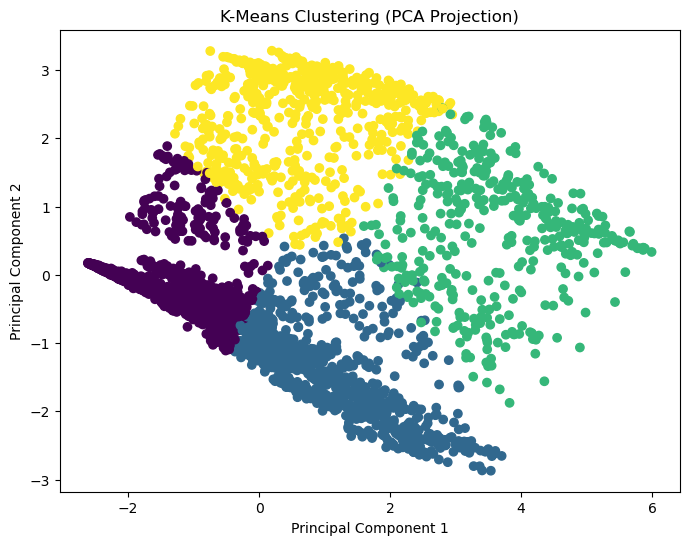

In [78]:
# Apply PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# Plot K-Means clusters
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], 
            c=df_clust['KMeans_Cluster'], cmap='viridis')
plt.title("K-Means Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

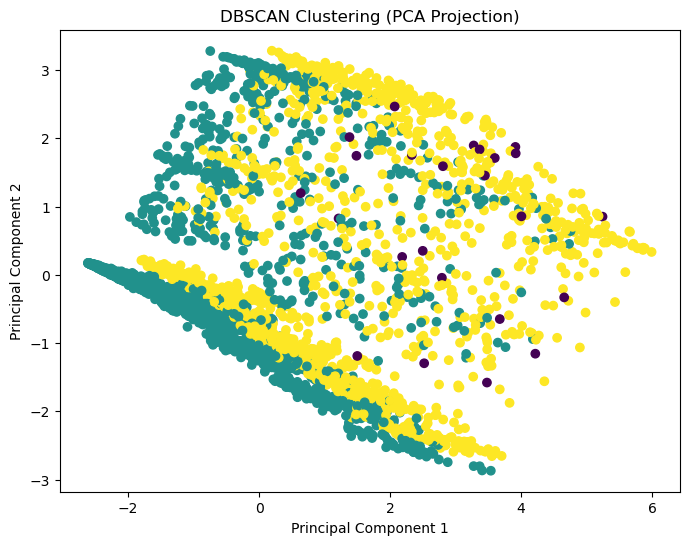

In [81]:
plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], 
            c=df_clust['DBSCAN_CLuster'])
plt.title("DBSCAN Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

## Evaluation and Performance Metrics:

**Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.**


In [82]:
# Silhouette Score for K-Means
kmeans_silhouette = silhouette_score(df_scaled, df_clust['KMeans_Cluster'])
print("Silhouette Score for K-Means:", kmeans_silhouette)

Silhouette Score for K-Means: 0.3072097778571253


In [85]:
# Remove noise points (-1)
db_labels = df_clust['DBSCAN_CLuster']
mask = db_labels != -1

# Calculate silhouette only if more than 1 cluster exists
if len(np.unique(db_labels[mask])) > 1:
    dbscan_silhouette = silhouette_score(df_scaled[mask], db_labels[mask])
    print("Silhouette Score for DBSCAN:", dbscan_silhouette)
else:
    print("Silhouette Score cannot be calculated (only one cluster found)")

Silhouette Score for DBSCAN: 0.24359620653866218
